# Training the model

In [1]:
import cv2
import numpy as np
from pathlib import Path
from typing import Dict, List, Optional, Union

def extract_sift_features(
    dataset_path: str,
    max_images_per_class: Optional[int] = None,
    image_extensions: tuple = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff'),
    concatenate_descriptors: bool = False
) -> Dict[str, Union[List[np.ndarray], np.ndarray]]:
    """
    Extract SIFT descriptors from images organized in subfolders (one per class).

    Args:
        dataset_path: Root directory containing labelled subfolders (e.g., 'split_data/train').
        max_images_per_class: Limit number of images to process per class (useful for large datasets).
        image_extensions: Allowed image file extensions.
        concatenate_descriptors: If True, returns a single numpy array of shape (N_desc, 128)
                                 per class by concatenating all descriptors from all images.
                                 If False, returns a list of arrays (one per image).

    Returns:
        Dictionary: {class_label: descriptors}
        - If concatenate_descriptors=False: list of numpy arrays (each shape (k, 128))
        - If concatenate_descriptors=True: single numpy array of shape (total_k, 128)
    """
    dataset_path = Path(dataset_path)
    if not dataset_path.exists():
        raise FileNotFoundError(f"Path {dataset_path} does not exist.")

    # Initialize SIFT detector
    sift = cv2.SIFT_create()

    label_to_descriptors = {}

    # Iterate over class subfolders
    class_folders = [f for f in dataset_path.iterdir() if f.is_dir()]

    for class_folder in class_folders:
        label = class_folder.name
        print(f"Processing class: {label}")

        # Collect all image files in this class folder
        image_files = [
            f for f in class_folder.iterdir()
            if f.is_file() and f.suffix.lower() in image_extensions
        ]

        if max_images_per_class:
            image_files = image_files[:max_images_per_class]

        if not image_files:
            print(f"  No images found in {label}, skipping.")
            continue

        all_desc = [] if concatenate_descriptors else []
        image_desc_list = []  # For list-of-arrays mode

        for img_file in image_files:
            # Read image as grayscale (SIFT works on single channel)
            img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"  Warning: Could not read {img_file}")
                continue

            # Detect keypoints and compute descriptors
            keypoints, descriptors = sift.detectAndCompute(img, None)

            if descriptors is not None:
                if concatenate_descriptors:
                    all_desc.append(descriptors)
                else:
                    image_desc_list.append(descriptors)
            else:
                print(f"  No keypoints found in {img_file}")

        if concatenate_descriptors and all_desc:
            # Vertically stack all descriptor arrays
            label_to_descriptors[label] = np.vstack(all_desc)
            print(f"  Extracted {label_to_descriptors[label].shape[0]} descriptors total")
        elif not concatenate_descriptors and image_desc_list:
            label_to_descriptors[label] = image_desc_list
            total = sum(d.shape[0] for d in image_desc_list)
            print(f"  Extracted descriptors from {len(image_desc_list)} images, total {total} descriptors")
        else:
            print(f"  No descriptors extracted for class {label}")

    return label_to_descriptors

In [2]:
train_features = extract_sift_features(
    dataset_path = 'splitted/train',
    max_images_per_class = None,
    image_extensions = ('.jpg'),
    concatenate_descriptors = False
)
train_features

Processing class: Plant_A
  Extracted descriptors from 17 images, total 12515 descriptors
Processing class: Plant_B
  Extracted descriptors from 16 images, total 29043 descriptors
Processing class: Plant_C
  Extracted descriptors from 16 images, total 20959 descriptors
Processing class: Plant_D
  Extracted descriptors from 15 images, total 15230 descriptors
Processing class: Plant_E
  Extracted descriptors from 9 images, total 6273 descriptors
Processing class: Plant_F
  Extracted descriptors from 4 images, total 3254 descriptors
Processing class: Plant_G
  Extracted descriptors from 12 images, total 19179 descriptors
Processing class: Plant_H
  Extracted descriptors from 11 images, total 14168 descriptors
Processing class: Plant_I
  Extracted descriptors from 7 images, total 2380 descriptors
Processing class: Plant_J
  Extracted descriptors from 11 images, total 6451 descriptors
Processing class: plant_K
  Extracted descriptors from 12 images, total 11216 descriptors
Processing class:

{'Plant_A': [array([[ 46.,  75., 148., ...,   4.,   1.,  31.],
         [  0.,   0.,   4., ...,   0.,   0.,   0.],
         [ 93.,  68.,   5., ...,   0.,   0.,   0.],
         ...,
         [118.,   7.,   2., ...,   0.,   0.,   0.],
         [  6.,  67.,  73., ...,   0.,   0.,   0.],
         [ 49., 135.,  20., ...,   0.,   0.,   0.]], dtype=float32),
  array([[104.,  31.,   0., ...,   4.,   1.,   5.],
         [ 35.,  49.,   3., ...,   6.,   1.,   0.],
         [  0.,   0.,   0., ...,  40.,   0.,   2.],
         ...,
         [ 32.,  19.,   0., ...,   0.,   0.,   0.],
         [132.,  14.,   0., ...,   3.,   0.,   0.],
         [ 30., 136.,  99., ...,   0.,   0.,   0.]], dtype=float32),
  array([[  0.,   0.,   0., ...,   0.,   1.,  43.],
         [  0.,   0.,   0., ..., 122.,  71.,   2.],
         [  9.,  15.,   3., ...,   2.,   0.,   0.],
         ...,
         [  6.,   0.,   0., ...,   1.,   2.,  91.],
         [ 11.,  42.,  86., ...,   0.,   1.,  57.],
         [ 41.,  72.,  29., .

In [3]:
test_features = extract_sift_features(
    dataset_path = 'splitted/test',
    max_images_per_class = None,
    image_extensions = ('.jpg'),
    concatenate_descriptors = False
)
test_features

Processing class: Plant_A
  Extracted descriptors from 5 images, total 3382 descriptors
Processing class: Plant_B
  Extracted descriptors from 4 images, total 7531 descriptors
Processing class: Plant_C
  Extracted descriptors from 4 images, total 6459 descriptors
Processing class: Plant_D
  Extracted descriptors from 4 images, total 4298 descriptors
Processing class: Plant_E
  Extracted descriptors from 3 images, total 2803 descriptors
Processing class: Plant_F
  Extracted descriptors from 1 images, total 1030 descriptors
Processing class: Plant_G
  Extracted descriptors from 4 images, total 6838 descriptors
Processing class: Plant_H
  Extracted descriptors from 3 images, total 4030 descriptors
Processing class: Plant_I
  Extracted descriptors from 2 images, total 832 descriptors
Processing class: Plant_J
  Extracted descriptors from 3 images, total 2242 descriptors
Processing class: plant_K
  Extracted descriptors from 3 images, total 2779 descriptors
Processing class: Plant_L
  Extra

{'Plant_A': [array([[ 57.,   9.,   1., ...,   0.,   0.,  23.],
         [  1.,   0.,   0., ...,  82.,   3.,   0.],
         [  0.,   0.,   0., ...,  47.,   1.,   1.],
         ...,
         [  1.,   4.,   4., ...,  22.,  19., 114.],
         [  0.,   0.,   0., ...,  11.,   3.,   2.],
         [ 57.,  26.,  40., ...,  21.,   7.,  16.]], dtype=float32),
  array([[ 44.,   5.,   0., ...,   0.,   0.,   1.],
         [165.,   1.,   0., ...,   6.,   2.,  17.],
         [ 31.,  27.,  80., ...,   0.,   3.,  58.],
         ...,
         [  0.,   0.,   0., ...,  43.,  29.,   3.],
         [  2.,  44., 144., ...,   0.,   1.,   1.],
         [ 11.,   3.,  35., ...,   0.,   0.,   0.]], dtype=float32),
  array([[ 10.,   1.,   3., ..., 133.,  17.,   1.],
         [ 42.,  12.,  38., ...,   0.,   0.,   0.],
         [  8.,   1.,   6., ...,   0.,   0.,   0.],
         ...,
         [ 30., 124.,  30., ...,   0.,   0.,   0.],
         [  9.,   0.,   3., ...,   2.,   0.,   0.],
         [  8.,   9.,   0., .

# Model training

In [4]:
import threadpoolctl

def _safe_get_version(self):
    try:
        get_config = getattr(self._dynlib, 'openblas_get_config', None)
        if get_config is None: return '0.0.0'
        get_config.restype = __import__('ctypes').c_char_p
        config = get_config()
        if config is None: return '0.0.0'
        config = config.split()
        return config[1].decode('utf-8') if config[0] == b'OpenBLAS' else '0.0.0'
    except Exception: return '0.0.0'

def _safe_get_num_threads(self):
    try:
        get_threads = getattr(self._dynlib, 'openblas_get_num_threads', None)
        return get_threads() if get_threads else 1
    except Exception: return 1

def _safe_get_extra_info(self):
    try:
        get_parallel = getattr(self._dynlib, 'openblas_get_parallel', None)
        if get_parallel is None:
            self.threading_layer = 'unknown'
            self.architecture = 'unknown'
            return
        val = get_parallel()
        self.threading_layer = 'openmp' if val == 2 else ('pthreads' if val == 1 else 'disabled')
        get_arch = getattr(self._dynlib, 'openblas_get_corename', None)
        self.architecture = get_arch().decode() if get_arch else 'unknown'
    except Exception:
        self.threading_layer = 'unknown'
        self.architecture = 'unknown'

threadpoolctl._OpenBLASModule.get_version     = _safe_get_version
threadpoolctl._OpenBLASModule.get_num_threads = _safe_get_num_threads
threadpoolctl._OpenBLASModule._get_extra_info = _safe_get_extra_info
print('threadpoolctl fully patched — safe to proceed')


threadpoolctl fully patched — safe to proceed


In [5]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

def build_codebook(label_to_descriptors, n_clusters=100, random_state=42):
    all_descriptors = []
    for desc_list in label_to_descriptors.values():
        all_descriptors.extend(desc_list)
    if not all_descriptors:
        raise ValueError('No descriptors found.')
    all_descriptors = np.vstack(all_descriptors).astype(np.float32)
    print(f'Total descriptors for clustering: {all_descriptors.shape}')
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        batch_size=2048,
        n_init=10
    )
    kmeans.fit(all_descriptors)
    print(f'Vocabulary built: {n_clusters} visual words')
    return kmeans

def compute_bovw_histograms(label_to_descriptors, kmeans):
    X, y = [], []
    for label, desc_list in label_to_descriptors.items():
        for desc in desc_list:
            if desc is None or len(desc) == 0:
                continue
            words = kmeans.predict(desc.astype(np.float32))
            hist = np.bincount(words, minlength=kmeans.n_clusters).astype(np.float32)
            hist /= (hist.sum() + 1e-8)
            X.append(hist)
            y.append(label)
    return np.asarray(X), np.asarray(y)

def train_orb_model(
    train_features,
    test_features,
    n_clusters=100,
    svm_kernel='linear',
    save_path='orb_model.pkl'
):
    kmeans = build_codebook(train_features, n_clusters=n_clusters)

    X_train, y_train = compute_bovw_histograms(train_features, kmeans)
    if len(X_train) == 0:
        raise ValueError('No training samples generated.')
    print(f'Training set: {X_train.shape}')

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    print('Training SVM...')
    svm = SVC(kernel=svm_kernel, random_state=42, probability=True)
    svm.fit(X_train_scaled, y_train)
    print('SVM trained!')

    if test_features:
        X_test, y_test = compute_bovw_histograms(test_features, kmeans)
        if len(X_test) > 0:
            X_test_scaled = scaler.transform(X_test)
            y_pred = svm.predict(X_test_scaled)
            print('\n===== RESULTS =====')
            print('Accuracy:', accuracy_score(y_test, y_pred))
            print(classification_report(y_test, y_pred))

            # Confusion matrix plot
            classes = sorted(list(set(y_test)))
            cm = confusion_matrix(y_test, y_pred, labels=classes)
            fig, ax = plt.subplots(figsize=(7, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=classes, yticklabels=classes, ax=ax)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
            ax.set_title('Confusion Matrix')
            plt.tight_layout()
            plt.show()

    joblib.dump({'svm': svm, 'kmeans': kmeans, 'scaler': scaler}, save_path)
    print(f'\nModel saved to {save_path}')
    return svm, kmeans, scaler


Total descriptors for clustering: (146181, 128)
Vocabulary built: 100 visual words
Training set: (136, 100)
Training SVM...
SVM trained!

===== RESULTS =====
Accuracy: 0.868421052631579
              precision    recall  f1-score   support

     Plant_A       0.83      1.00      0.91         5
     Plant_B       1.00      1.00      1.00         4
     Plant_C       1.00      1.00      1.00         4
     Plant_D       0.80      1.00      0.89         4
     Plant_E       1.00      0.33      0.50         3
     Plant_F       0.00      0.00      0.00         1
     Plant_G       1.00      1.00      1.00         4
     Plant_H       1.00      1.00      1.00         3
     Plant_I       1.00      1.00      1.00         2
     Plant_J       1.00      1.00      1.00         3
     Plant_L       0.00      0.00      0.00         2
     plant_K       1.00      1.00      1.00         3

    accuracy                           0.87        38
   macro avg       0.80      0.78      0.77        38
we

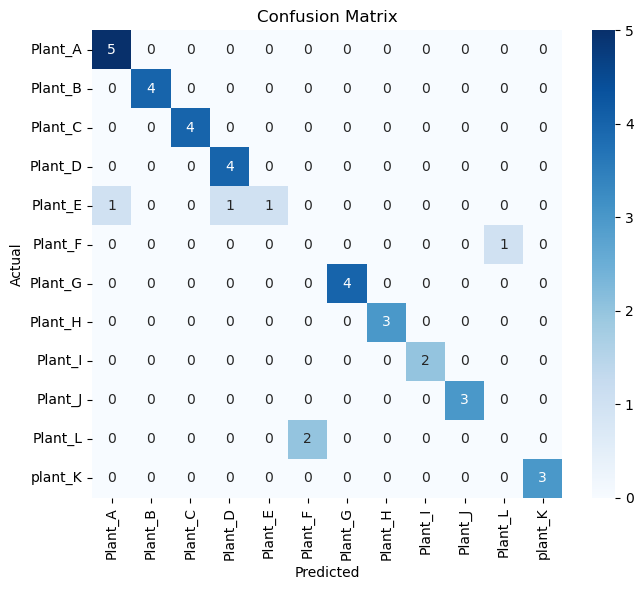


Model saved to orb_model.pkl


In [6]:
#using train_features and test_features (defined in cells 2 & 3 above)
svm_model, kmeans_model, scaler_model = train_orb_model(
    train_features=train_features,
    test_features=test_features,
    n_clusters=100
)


In [7]:
# Image Similarity — find most similar images

from sklearn.metrics.pairwise import cosine_similarity

# Build flat lists for lookup
train_label_list, train_img_index_list = [], []
for label, desc_list in train_features.items():
    for i in range(len(desc_list)):
        train_label_list.append(label)
        train_img_index_list.append(i)
train_labels_arr = np.array(train_label_list)

# Rebuild X_train histograms for similarity
X_train_sim, y_train_sim = compute_bovw_histograms(train_features, kmeans_model)
X_train_sim_scaled = scaler_model.transform(X_train_sim)

def find_similar_images(query_label, query_idx=0, top_k=3):
    query_desc = [train_features[query_label][query_idx]]
    query_hist, _ = compute_bovw_histograms({query_label: query_desc}, kmeans_model)
    query_scaled = scaler_model.transform(query_hist)
    sims = cosine_similarity(query_scaled, X_train_sim_scaled)[0]
    sorted_idx = np.argsort(sims)[::-1]
    results = []
    for idx in sorted_idx:
        if train_labels_arr[idx] == query_label and train_img_index_list[idx] == query_idx:
            continue
        results.append((train_labels_arr[idx], train_img_index_list[idx], sims[idx]))
        if len(results) == top_k:
            break
    return results

# Show similar images for first image in each class
for cls in sorted(train_features.keys()):
    similar = find_similar_images(cls, 0, top_k=3)
    print(f'Query: {cls}[0]  →  Top-3 most similar:')
    for rank, (lbl, idx, score) in enumerate(similar, 1):
        print(f'  {rank}. {lbl}[{idx}]  similarity={score:.4f}')
    print()


Query: Plant_A[0]  →  Top-3 most similar:
  1. Plant_A[12]  similarity=0.6228
  2. Plant_A[15]  similarity=0.5520
  3. Plant_A[1]  similarity=0.5503

Query: Plant_B[0]  →  Top-3 most similar:
  1. Plant_B[3]  similarity=0.6486
  2. Plant_B[15]  similarity=0.6219
  3. Plant_B[8]  similarity=0.5976

Query: Plant_C[0]  →  Top-3 most similar:
  1. Plant_C[13]  similarity=0.5937
  2. Plant_C[7]  similarity=0.5648
  3. Plant_C[1]  similarity=0.5384

Query: Plant_D[0]  →  Top-3 most similar:
  1. Plant_D[14]  similarity=0.3504
  2. Plant_D[8]  similarity=0.3343
  3. Plant_H[9]  similarity=0.2957

Query: Plant_E[0]  →  Top-3 most similar:
  1. Plant_H[3]  similarity=0.3011
  2. Plant_E[8]  similarity=0.2546
  3. Plant_L[1]  similarity=0.2479

Query: Plant_F[0]  →  Top-3 most similar:
  1. Plant_L[1]  similarity=0.5766
  2. Plant_L[0]  similarity=0.4805
  3. Plant_J[10]  similarity=0.4634

Query: Plant_G[0]  →  Top-3 most similar:
  1. Plant_G[9]  similarity=0.7536
  2. Plant_G[2]  similarity=0

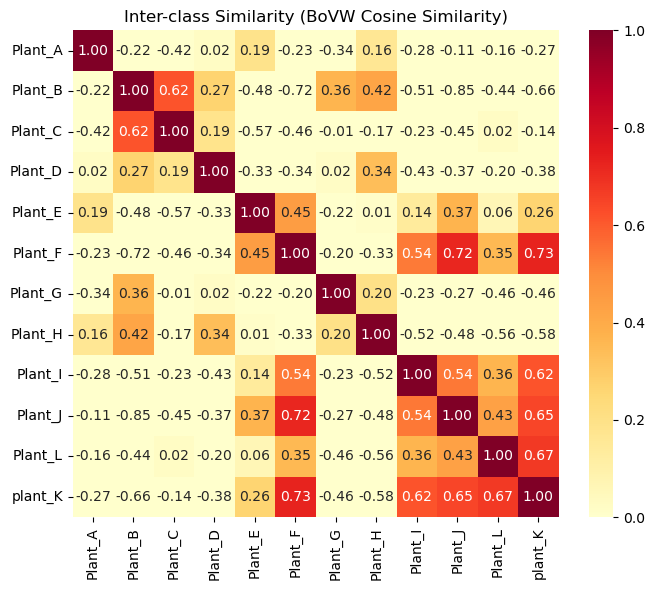

Most similar class pairs:
  Plant_A  is most similar to  Plant_E  (sim=0.189)
  Plant_B  is most similar to  Plant_C  (sim=0.616)
  Plant_C  is most similar to  Plant_B  (sim=0.616)
  Plant_D  is most similar to  Plant_H  (sim=0.339)
  Plant_E  is most similar to  Plant_F  (sim=0.447)
  Plant_F  is most similar to  plant_K  (sim=0.729)
  Plant_G  is most similar to  Plant_B  (sim=0.363)
  Plant_H  is most similar to  Plant_B  (sim=0.419)
  Plant_I  is most similar to  plant_K  (sim=0.616)
  Plant_J  is most similar to  Plant_F  (sim=0.721)
  Plant_L  is most similar to  plant_K  (sim=0.674)
  plant_K  is most similar to  Plant_F  (sim=0.729)


In [8]:
# Inter-class Similarity Heatmap

classes_sorted = sorted(train_features.keys())
n_classes = len(classes_sorted)
sim_matrix = np.zeros((n_classes, n_classes))

# Mean histogram per class
class_mean_hists = {}
start = 0
for label in classes_sorted:
    n_imgs = len(train_features[label])
    class_mean_hists[label] = X_train_sim_scaled[start:start + n_imgs].mean(axis=0)
    start += n_imgs

for i, c1 in enumerate(classes_sorted):
    for j, c2 in enumerate(classes_sorted):
        h1 = class_mean_hists[c1].reshape(1, -1)
        h2 = class_mean_hists[c2].reshape(1, -1)
        sim_matrix[i, j] = cosine_similarity(h1, h2)[0, 0]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=classes_sorted, yticklabels=classes_sorted,
            ax=ax, vmin=0, vmax=1)
ax.set_title('Inter-class Similarity (BoVW Cosine Similarity)')
plt.tight_layout()
plt.show()

print('Most similar class pairs:')
for i, c1 in enumerate(classes_sorted):
    row = sim_matrix[i].copy()
    row[i] = 0
    j = np.argmax(row)
    print(f'  {c1}  is most similar to  {classes_sorted[j]}  (sim={row[j]:.3f})')